In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("../data/cleaned/fraud_features.csv")
print(df.shape)

(15419, 50)


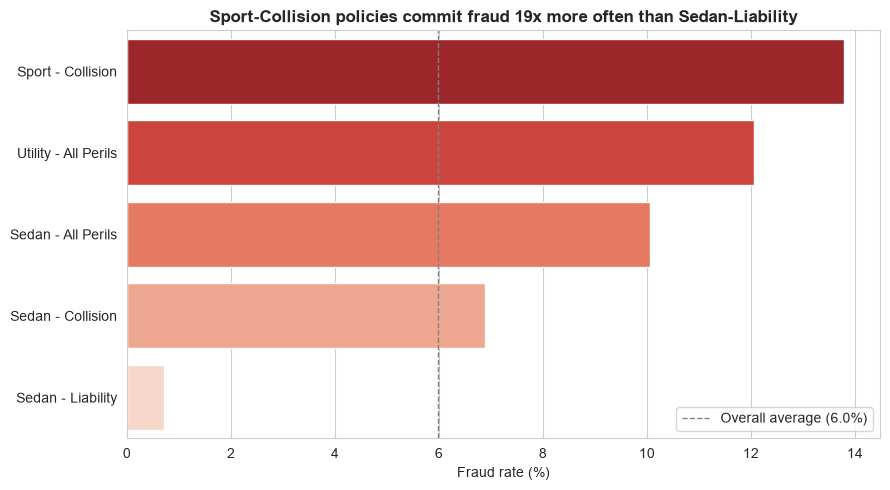

In [2]:
policy_stats = (df.groupby("PolicyType")["FraudFound_P"]
                 .agg(["count", "mean"])
                 .rename(columns={"count": "n_claims", "mean": "fraud_rate"})
                 .query("n_claims >= 50")
                 .sort_values("fraud_rate", ascending=False))
policy_stats["fraud_rate"] *= 100

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=policy_stats["fraud_rate"], y=policy_stats.index, hue=policy_stats.index,
            palette="Reds_r", legend=False, ax=ax)
ax.axvline(df["FraudFound_P"].mean() * 100, color="gray", linestyle="--", linewidth=1,
           label=f"Overall average ({df['FraudFound_P'].mean()*100:.1f}%)")
ax.set_title("Sport-Collision policies commit fraud 19x more often than Sedan-Liability",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fraud rate (%)")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.savefig("../images/01_fraud_by_policy_type.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Fraud rate varies nearly 19x by policy type — Sport-Collision (13.79%) and
Utility-All Perils (12.06%) are the riskiest, while Sedan-Liability (0.72%) is almost
fraud-free. Confirmed statistically (χ²=437.49, p<0.001, Cramér's V=0.168).

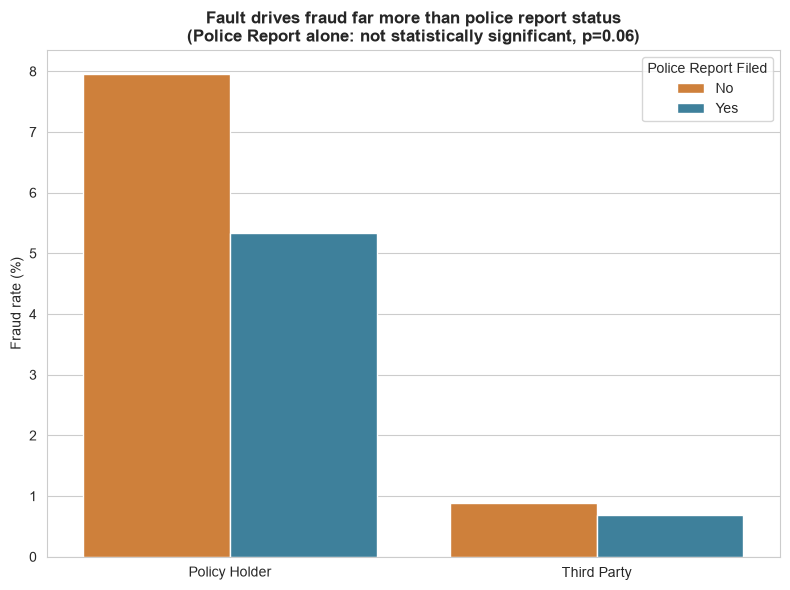

In [3]:
grouped = (df.groupby(["Fault", "PoliceReportFiled"])["FraudFound_P"]
           .mean().mul(100).reset_index())

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=grouped, x="Fault", y="FraudFound_P", hue="PoliceReportFiled",
            palette=["#E67E22", "#2E86AB"], ax=ax)
ax.set_title("Fault drives fraud far more than police report status\n(Police Report alone: not statistically significant, p=0.06)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Fraud rate (%)")
ax.set_xlabel("")
ax.legend(title="Police Report Filed")
plt.tight_layout()
plt.savefig("../images/02_fault_vs_police_report.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Fault status drives fraud far more than police report status. Policy-holder-at-fault
claims are 6-9x more fraud-prone than third-party-at-fault claims, regardless of whether a police
report was filed. Police Report alone failed to reach statistical significance (p=0.06) —
its apparent effect in early cross-tabs was confounded with Fault.

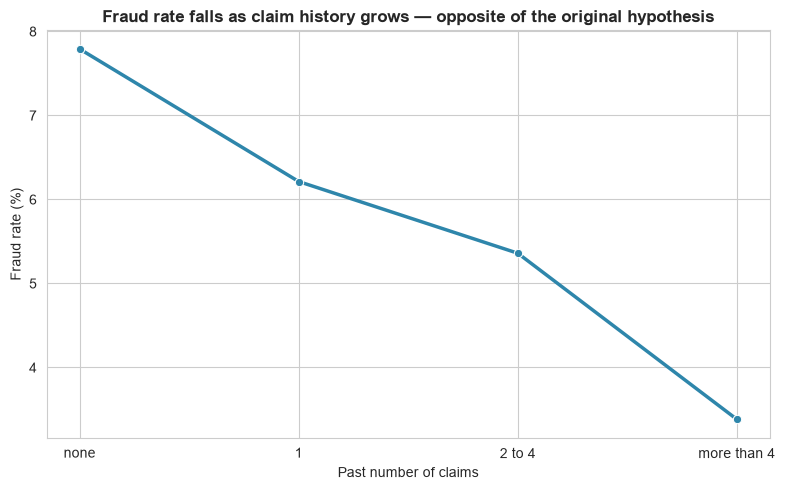

In [4]:
order = ["none", "1", "2 to 4", "more than 4"]
claims_stats = df.groupby("PastNumberOfClaims", observed=True)["FraudFound_P"].mean().reindex(order) * 100

fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(x=order, y=claims_stats.values, marker="o", linewidth=2.5, color="#2E86AB", ax=ax)
ax.set_title("Fraud rate falls as claim history grows — opposite of the original hypothesis",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Past number of claims")
ax.set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.savefig("../images/03_past_claims_trend.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Fraud rate falls as claim history grows — from 7.79% (no past claims) to 3.38%
(more than 4 past claims) — the opposite of the original hypothesis (H5 rejected). Confirmed with
a Spearman trend test (ρ=-0.058, p<0.001). Likely explanation: repeat claimants are established,
verified customers, while first-time claimants are harder to vet.

In [6]:
df["Recent_Address_Change"] = df["AddressChange_Claim"].isin(["under 6 months", "2 to 3 years"]).astype(int)
print(df["Recent_Address_Change"].value_counts())

Recent_Address_Change
0    15124
1      295
Name: count, dtype: int64


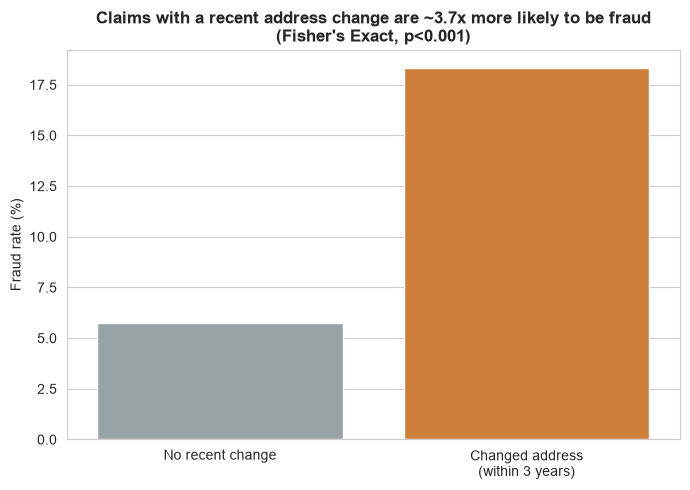

In [7]:
addr_stats = (df.groupby("Recent_Address_Change")["FraudFound_P"].mean() * 100)
labels = ["No recent change", "Changed address\n(within 3 years)"]

fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=labels, y=addr_stats.values, hue=labels, palette=["#95A5A6", "#E67E22"],
            legend=False, ax=ax)
ax.set_title("Claims with a recent address change are ~3.7x more likely to be fraud\n(Fisher's Exact, p<0.001)",
             fontsize=12, fontweight="bold")
ax.set_ylabel("Fraud rate (%)")
plt.tight_layout()
plt.savefig("../images/04_address_change.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Claims with a recent address change (within 3 years) are about 3.7x more likely
to be fraudulent than claims with no address change, confirmed with Fisher's Exact Test
(OR=3.68, p<0.001) — chosen over chi-square because the strictest sub-category had only 4
observations, too few for chi-square's assumptions to hold reliably.

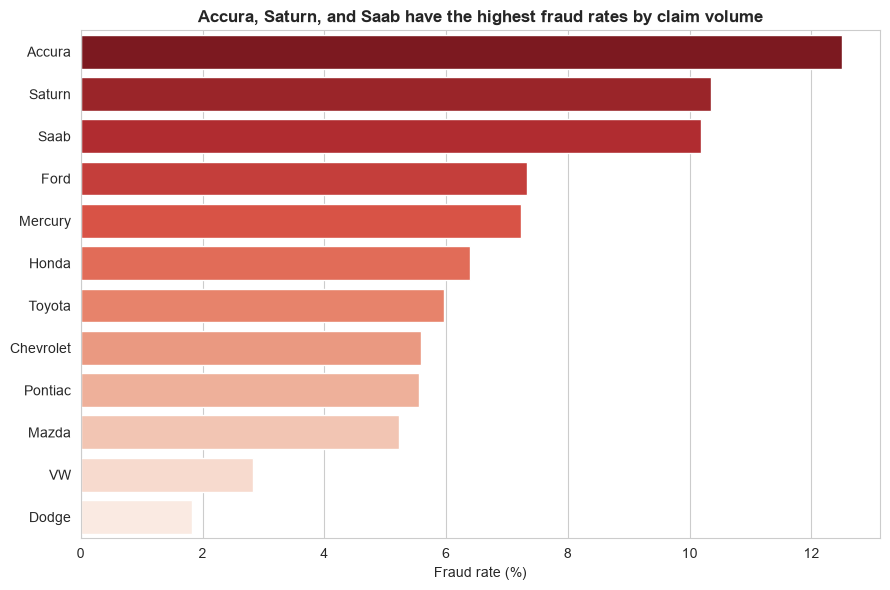

In [8]:
make_stats = (df.groupby("Make")["FraudFound_P"].agg(["count", "mean"])
              .rename(columns={"count": "n_claims", "mean": "fraud_rate"})
              .query("n_claims >= 50")
              .sort_values("fraud_rate", ascending=False))
make_stats["fraud_rate"] *= 100

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=make_stats["fraud_rate"], y=make_stats.index, hue=make_stats.index,
            palette="Reds_r", legend=False, ax=ax)
ax.set_title("Accura, Saturn, and Saab have the highest fraud rates by claim volume",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fraud rate (%)")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig("../images/05_fraud_by_make.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** Accura, Saturn, and Saab have the highest fraud rates per claim filed among makes
with 50+ claims, useful for prioritizing which claims an SIU team reviews first when investigator
capacity is limited.

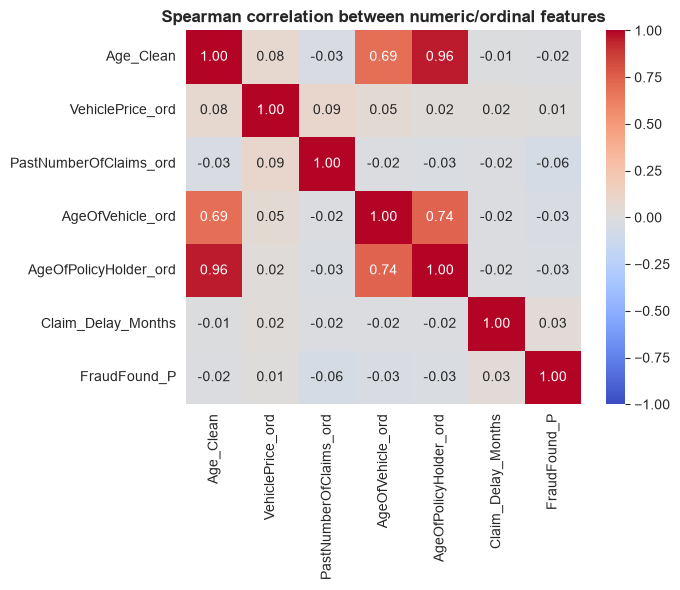

In [9]:
num_cols = ["Age_Clean", "VehiclePrice_ord", "PastNumberOfClaims_ord", "AgeOfVehicle_ord",
            "AgeOfPolicyHolder_ord", "Claim_Delay_Months", "FraudFound_P"]
corr = df[num_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Spearman correlation between numeric/ordinal features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/06_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Takeaway:** No numeric/ordinal feature shows a strong linear or monotonic relationship with
fraud on its own — the strongest correlates (PastNumberOfClaims_ord, Claim_Delay_Months) are
weak in isolation, suggesting fraud here is driven more by categorical combinations (policy
type, fault, address change) than by single continuous variables. This motivates using a
model like Random Forest, which can capture interactions rather than relying on one variable.